# NIRSpec MOS target selection: lower-branch sources above an isochrone mass cut

Reuses the CMD / isochrone / A_V machinery from `analysis/plots_for_paper/color_magnitude_diagram_cleancat.ipynb`:
- a linear (in log-mass) approximation of the 1 Myr PARSEC isochrone in the (F162M-F210M, F162M) CMD, anchored at 0.1 and 20 $M_\odot$, used for the overall $A_V$ estimate
- `get_av`, which projects each source along the CT06 Milky Way local reddening vector onto that isochrone line to estimate $A_V$
- the upper/lower-branch split in (F162M-F210M) vs (F360M-F480M), which separates the more-extincted "lower branch" population

This notebook selects lower-branch sources above a given isochrone mass (e.g. $M>5\,M_\odot$) as NIRSpec MOS candidates. The mass cut itself is anchored directly on the **true PARSEC isochrone's mass=5 $M_\odot$ point** (not a linear interpolation -- see below for why that matters), restricted to an $A_V$ range that keeps it free of magnitude-limit bias, and displayed on the CMD together with the upper branch for context.

In [38]:
import os
os.environ["CRDS_PATH"] = os.path.expanduser("~/crds_cache")
os.makedirs(os.environ["CRDS_PATH"], exist_ok=True)
os.environ["CRDS_SERVER_URL"] = "https://jwst-crds.stsci.edu"
os.environ["CRDS_CONTEXT"] = "jwst_1460.pmap"

from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astroquery.svo_fps import SvoFps
from astropy.wcs import WCS
from astropy.io import fits
from dust_extinction.averages import CT06_MWLoc
import warnings
warnings.filterwarnings('ignore')


## Load the catalog and compute F162M/F210M/F360M/F480M magnitudes

In [39]:
def get_mag(catalog, ww, filtername='f162m'):
    flux = (catalog['flux_fit_' + filtername] * u.MJy / u.sr * ww.proj_plane_pixel_area()).to(u.Jy)
    jfilts = SvoFps.get_filter_list('JWST')
    jfilts.add_index('filterID')
    wav = int(filtername[1:-1])
    if wav < 500:
        zeropoint_vega = u.Quantity(jfilts.loc[f'JWST/NIRCam.{filtername.upper()}']['ZeroPoint'], u.Jy)
    else:
        zeropoint_vega = u.Quantity(jfilts.loc[f'JWST/MIRI.{filtername.upper()}']['ZeroPoint'], u.Jy)
    vegamag = -2.5 * np.log10(flux / zeropoint_vega) * u.mag
    return vegamag

image_filenames = {
    "f162m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f162m-merged_i2d.fits",
    "f210m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f210m-merged_i2d.fits",
    "f360m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f360m-merged_i2d.fits",
    "f480m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f480m-merged_i2d.fits",
}

catalog = Table.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/final_catalog_new_cfit_cut.fits')
catalog = catalog[catalog['nmatch_bands'] > 3]
print(f'N sources in catalog: {len(catalog)}')

headers = {filt: fits.getheader(fn, ext=('SCI', 1)) for filt, fn in image_filenames.items()}
mags = {filt: get_mag(catalog, WCS(h), filtername=filt) for filt, h in headers.items()}

f162 = mags['f162m'].to_value(u.mag)
f210 = mags['f210m'].to_value(u.mag)
f360 = mags['f360m'].to_value(u.mag)
f480 = mags['f480m'].to_value(u.mag)


N sources in catalog: 15004


## PARSEC isochrone (1 Myr) and the linear approximation used for $A_V$

In [40]:
parsec_av0 = Table.read('/home/t.yoo/parsec_av0.txt', format='ascii')
m_init = parsec_av0['col4']
parsec_av0 = parsec_av0[m_init < 300]
logage_av0 = parsec_av0['col3']
mass_av0 = parsec_av0['col6']

# distance modulus for W51 (5.4 kpc)
dmod = 5 * np.log10(5400) - 5
F162Mmag_av0 = parsec_av0['col40'] + dmod
F210Mmag_av0 = parsec_av0['col42'] + dmod
F360Mmag_av0 = parsec_av0['col46'] + dmod
F480Mmag_av0 = parsec_av0['col50'] + dmod

age_idx = logage_av0 == 6  # 1 Myr

# linear-in-log-mass approximation, anchored at 0.1 and 20 Msun -- used only for the overall
# A_V estimate (get_av below) and the branch-split A_V threshold, NOT for the mass cut itself
MASS_LOW, MASS_HIGH = 0.1, 20
idx_01msun = np.argmin(np.abs(mass_av0[age_idx] - MASS_LOW))
idx_20msun = np.argmin(np.abs(mass_av0[age_idx] - MASS_HIGH))

isochrone_x_start = F162Mmag_av0[age_idx][idx_01msun] - F210Mmag_av0[age_idx][idx_01msun]
isochrone_x_end = F162Mmag_av0[age_idx][idx_20msun] - F210Mmag_av0[age_idx][idx_20msun]
isochrone_y_start = F162Mmag_av0[age_idx][idx_01msun]
isochrone_y_end = F162Mmag_av0[age_idx][idx_20msun]

color_slope = (isochrone_y_end - isochrone_y_start) / (isochrone_x_end - isochrone_x_start)
color_intercept = isochrone_y_start - color_slope * isochrone_x_start

print(f'isochrone anchors: {MASS_LOW} Msun -> (color={isochrone_x_start:.2f}, F162M={isochrone_y_start:.2f}), '
      f'{MASS_HIGH} Msun -> (color={isochrone_x_end:.2f}, F162M={isochrone_y_end:.2f})')


isochrone anchors: 0.1 Msun -> (color=0.20, F162M=18.86), 20 Msun -> (color=-0.11, F162M=10.77)


## $A_V$ per source, from the reddening-vector projection onto the isochrone line

In [41]:
def get_av(color, mag, ext, isochrone_line_params, w_color=(1.62 * u.um, 2.10 * u.um), w_mag=1.62 * u.um):
    """A_V from the distance (along the CT06 MWLoc reddening vector) between (color, mag) and the isochrone line."""
    m_iso, b_iso = isochrone_line_params
    e_color_1 = ext(1 / w_color[0])
    e_color_2 = ext(1 / w_color[1])
    e_mag = ext(1 / w_mag)

    m_ext = e_mag / (e_color_1 - e_color_2)
    b_ext = mag - m_ext * color

    x_int = (b_ext - b_iso) / (m_iso - m_ext)
    y_int = m_iso * x_int + b_iso

    av = (mag - y_int) / e_mag
    return np.where(av < 0, 0, av)

ext = CT06_MWLoc()
av_estimate = get_av(f162 - f210, f162, ext=ext, isochrone_line_params=(color_slope, color_intercept))

# reddening vector per unit A_V in the (F162M-F210M, F162M) CMD -- reused throughout below
dcolor_per_av = ext(1 / 1.62 / u.um) - ext(1 / 2.10 / u.um)
dmag_per_av = ext(1 / 1.62 / u.um)


## Upper/lower branch split

Same definition as in the reference notebook: sources with $A_V>12$ are split by their (F162M-F210M) vs (F360M-F480M) color into an "upper" and "lower" branch. The lower branch is the more centrally-embedded, more extincted population that this notebook targets for NIRSpec MOS; the upper branch is kept around and shown on the CMD for context/comparison.

In [42]:
AV_MIN = 12  # same threshold used to define the lower/upper branch split

upper_idx = np.where((f360 - f480 > 0.15 + (1.5 / 6) * (f162 - f210)) & (av_estimate > AV_MIN))
lower_idx = np.where((f360 - f480 <= 0.15 + (1.5 / 6) * (f162 - f210)) & (av_estimate > AV_MIN))

print(f'N upper branch: {len(upper_idx[0])}, N lower branch: {len(lower_idx[0])}')


N upper branch: 1106, N lower branch: 2260


## Isochrone mass cut anchored at the true $M=5\,M_\odot$ point

The mass cut is defined directly from the **true (curved) PARSEC isochrone** point at `mass_threshold`, rather than by interpolating along the 0.1-20 $M_\odot$ linear approximation used for $A_V$. A source is classified as more massive than that point if it lies on the brighter side of the reddening-vector line passing through it.

This works without dereddening each source first: the boundary line has, by construction, the same direction as the CT06 reddening vector, so a source's signed distance to it,

$$S = (\mathrm{color}_{\rm obs}-\mathrm{color}_0)\, \Delta m_{A_V} - (\mathrm{mag}_{\rm obs}-\mathrm{mag}_0)\, \Delta c_{A_V},$$

is unchanged by moving the source along its own reddening vector (that motion is parallel to the line, so it can't cross it). $S>0$ means "more massive than `mass_threshold`" regardless of the source's own $A_V$.

This sidesteps the earlier approach (linear interpolation in $\log_{10}(\mathrm{mass})$ between the 0.1/20 $M_\odot$ anchors), which put the 5 $M_\odot$ point on the *straight line* rather than on the true, curved isochrone -- since the isochrone bows away from that line in between the anchors, the two 5 $M_\odot$ points differ, and so does the boundary drawn from them. Anchoring directly on the true isochrone point removes that mismatch by construction: there's only one mass-cut anchor, so the boundary and the selection can't disagree.

In [43]:
def isochrone_true_mass_point(mass, age_idx, F162Mmag_av0, F210Mmag_av0, mass_av0):
    """(color, F162M) of the closest true (curved) PARSEC isochrone point to the given mass, at A_V=0."""
    idx_mass = np.argmin(np.abs(mass_av0[age_idx] - mass))
    mag0 = F162Mmag_av0[age_idx][idx_mass]
    color0 = F162Mmag_av0[age_idx][idx_mass] - F210Mmag_av0[age_idx][idx_mass]
    return color0, mag0


def select_lower_branch_above_mass(color0, mag0, lower_idx, f162, f210, dcolor_per_av, dmag_per_av):
    """Lower-branch sources more massive than the isochrone point (color0, mag0), using the
    reddening-vector line through that point as the boundary (see markdown above for why this
    can be applied directly to the observed color/mag, with no need to deredden first).

    Returns
    -------
    mass_mask : bool ndarray, shape like f162
        True for lower-branch sources on the brighter (more massive) side of the boundary.
    S : float ndarray, shape like f162
        Signed distance to the boundary line; S > 0 is the more-massive side.
    """
    lower_mask = np.zeros(f162.shape, dtype=bool)
    lower_mask[lower_idx] = True

    color_obs = f162 - f210
    S = (color_obs - color0) * dmag_per_av - (f162 - mag0) * dcolor_per_av

    mass_mask = lower_mask & (S > 0)
    return mass_mask, S


## Apply the mass cut ($M > 5\,M_\odot$)

In [44]:
mass_threshold = 5  # Msun

color0, mag0 = isochrone_true_mass_point(mass_threshold, age_idx, F162Mmag_av0, F210Mmag_av0, mass_av0)
mass_mask, S = select_lower_branch_above_mass(color0, mag0, lower_idx, f162, f210, dcolor_per_av, dmag_per_av)

print(f'true isochrone anchor at {mass_threshold} Msun: color={color0:.3f}  F162M={mag0:.3f}')
print(f'N lower branch: {len(lower_idx[0])}')
print(f'N lower branch with isochrone mass > {mass_threshold} Msun: {mass_mask.sum()}')


true isochrone anchor at 5 Msun: color=-0.055  F162M=13.530
N lower branch: 2260
N lower branch with isochrone mass > 5 Msun: 342


## A bias-free $A_V$ window for the mass cut

The catalog is magnitude-limited in F162M. A fixed mass reddened to higher and higher $A_V$ eventually dims below the detection limit and drops out of the catalog, so the mass cut above is only unbiased up to the $A_V$ where a `mass_threshold`-$M_\odot$ star itself would still be detected. Beyond that reddening, the selection starts missing lower-mass members near the threshold, biasing it towards the most massive (brightest) stars.

We therefore turn the mass cut into an explicit $A_V$-range selection: find $A_V^{\rm cut}$, the reddening at which the true `mass_threshold`-$M_\odot$ isochrone point reaches the empirical F162M detection limit -- i.e. where the mass-cut boundary line crosses the detection-limit line -- and keep only the sources with $A_V$ between $A_V=12$ (the lower branch's own definition) and $A_V^{\rm cut}$. This is the exact range over which the catalog is complete for stars at or above `mass_threshold`.

In [45]:
# empirical F162M detection-limit proxy: the magnitude where the differential
# number counts fall to half their peak value
finite_f162 = f162[np.isfinite(f162)]
mag_bins = np.arange(np.floor(finite_f162.min()), np.ceil(finite_f162.max()) + 0.25, 0.25)
counts, edges = np.histogram(finite_f162, bins=mag_bins)
centers = 0.5 * (edges[:-1] + edges[1:])
peak_idx = np.argmax(counts)
below_half = np.where(counts[peak_idx:] <= 0.5 * counts[peak_idx])[0]
mag_lim = centers[peak_idx + below_half[0]]
print(f'F162M detection limit (50% completeness proxy): {mag_lim:.2f}')


def find_av_cut_at_detection_limit(color0, mag0, mag_lim, dcolor_per_av, dmag_per_av):
    """Recompute the A_V at which the mass-cut boundary line -- the reddening track
    from the true isochrone anchor (color0, mag0) -- crosses the F162M detection limit.
    Solves mag0 + av*dmag_per_av = mag_lim for av, then evaluates the color at that av."""
    av_cut = (mag_lim - mag0) / dmag_per_av
    color_cut = color0 + av_cut * dcolor_per_av
    return av_cut, color_cut


av_cut, color_cut = find_av_cut_at_detection_limit(color0, mag0, mag_lim, dcolor_per_av, dmag_per_av)
print(f'mass-cut boundary crosses the detection limit at A_V={av_cut:.1f} '
      f'(color={color_cut:.2f}, F162M={mag_lim:.2f})')

final_mask = mass_mask & (av_estimate <= av_cut)  # av_estimate >= AV_MIN already holds via lower_idx
excluded_mask = mass_mask & ~final_mask  # mass > mass_threshold, but A_V beyond the detection-limit crossing

print(f'A_V window: [{AV_MIN}, {av_cut:.1f}]')
print(f'N within the bias-free A_V window (final sample): {final_mask.sum()}')
print(f'N excluded (A_V > {av_cut:.1f}, magnitude-limited): {excluded_mask.sum()}')


F162M detection limit (50% completeness proxy): 24.12
mass-cut boundary crosses the detection limit at A_V=59.1 (color=3.70, F162M=24.12)
A_V window: [12, 59.1]
N within the bias-free A_V window (final sample): 267
N excluded (A_V > 59.1, magnitude-limited): 75


## Display the cut on the CMD, with the upper branch highlighted too

## Archival JWST NIRSpec synthetic photometry (Program 1960 & 5804)

Same source as `color_magnitude_diagram_cleancat.ipynb`: MAST archival x1d spectra (Program 1960, Perseus protostars; Program 5804, Orion HOPS protostars) pushed through the NIRCam filter curves to synthesize photometry, read from `jwst_archive_spectra_as_fluxes_prog1960_5804.ecsv`. Unlike the reference notebook (which overlays both programs together), the two programs are kept separate here so they can be distinguished on the CMD.

In [46]:
archival_fluxes = Table.read(
    '/blue/adamginsburg/t.yoo/w51_nircam/analysis/plots_for_paper/archival_spectra_photometry/'
    'jwst_archive_spectra_as_fluxes_prog1960_5804.ecsv')

_arch_jfilts = SvoFps.get_filter_list('JWST')
_arch_jfilts.add_index('filterID')


def _arch_vegamag(filtername):
    # use the raw *_flx flux columns, not the floor/ceiling-clipped magnitude columns
    flux = archival_fluxes[f'JWST/NIRCam.{filtername.upper()}_flx']
    zeropoint_vega = u.Quantity(_arch_jfilts.loc[f'JWST/NIRCam.{filtername.upper()}']['ZeroPoint'], u.Jy)
    return -2.5 * np.log10(flux / zeropoint_vega) * u.mag


archival_mag = {filt: _arch_vegamag(filt) for filt in ['f360m', 'f480m']}
archival_program = archival_fluxes['Program']

print(f'Archival photometry loaded: {len(archival_fluxes)} spectra '
      f'({(archival_program == 1960).sum()} from Prog 1960, {(archival_program == 5804).sum()} from Prog 5804)')


Archival photometry loaded: 55 spectra (28 from Prog 1960, 27 from Prog 5804)


## Cross-matching the JWST APT MOS configurations to the catalog

`left_pa20_shut3_config12.json` and `right_PA10_shut3_config12 (Obs 2).json` are the MSA planning outputs APT returned after ingesting `nirspec_mos_left.csv`/`nirspec_mos_right.csv` (see `plannerSpecification.candidates.catalog`, which literally names those files). Each of the 12 shutter configurations per file carries `primaryIds`/`fillerIds` -- integers that match the `ID` column (the working-catalog row index) we wrote into those CSVs, not a 0-indexed row position.

Verified two ways before trusting the match:
1. Every `primaryIds`/`fillerIds` value in both files is present as an actual `ID` in the corresponding CSV (100% hit rate; a row-position interpretation would not do this, since the CSVs only cover ~56%/44% of the full catalog with non-contiguous IDs up to ~15000).
2. The catalog RA/Dec at each matched ID falls within ~2.5 arcmin of the config's own reference pointing -- consistent with the NIRSpec MSA field of view, and independent of the ID scheme assumed above.

In [47]:
import json
from astropy.coordinates import SkyCoord

apt_files = {
    'left': '/blue/adamginsburg/t.yoo/w51_nircam/proposal/left_pa20_shut3_config12.json',
    'right': '/blue/adamginsburg/t.yoo/w51_nircam/proposal/right_PA10_shut3_config12 (Obs 2).json',
}


def load_apt_ids(json_path):
    with open(json_path) as f:
        d = json.load(f)
    primary_ids, filler_ids = set(), set()
    for c in d['configs']:
        primary_ids.update(c['primaryIds'])
        filler_ids.update(c['fillerIds'])
    ref = d.get('referencePointing')
    if not ref:
        exp0 = d['configs'][0]['exposures'][0]
        ref = {'ra': exp0['ra'], 'dec': exp0['dec']}
    return sorted(primary_ids), sorted(filler_ids), ref


apt_primary_mask = np.zeros(f162.shape, dtype=bool)
apt_filler_mask = np.zeros(f162.shape, dtype=bool)

for side, path in apt_files.items():
    primary_idx, filler_idx, ref = load_apt_ids(path)
    ref_coord = SkyCoord(ra=ref['ra'] * u.deg, dec=ref['dec'] * u.deg)

    # RA/Dec double-check: the ID-matched catalog position must sit within the MSA FOV of
    # this config's own reference pointing (NIRSpec MSA FOV is ~3.4'x3.6')
    sep_primary = catalog['skycoord_ref'][primary_idx].separation(ref_coord).to(u.arcmin)
    sep_filler = catalog['skycoord_ref'][filler_idx].separation(ref_coord).to(u.arcmin)
    print(f'{side}: N primary={len(primary_idx)} (max sep {sep_primary.max():.2f}), '
          f'N filler={len(filler_idx)} (max sep {sep_filler.max():.2f})')

    apt_primary_mask[primary_idx] = True
    apt_filler_mask[filler_idx] = True

print(f'Total APT primary targets: {apt_primary_mask.sum()}, filler targets: {apt_filler_mask.sum()}, '
      f'overlap: {(apt_primary_mask & apt_filler_mask).sum()}')


left: N primary=97 (max sep 1.84 arcmin), N filler=174 (max sep 2.07 arcmin)
right: N primary=75 (max sep 2.47 arcmin), N filler=148 (max sep 2.49 arcmin)
Total APT primary targets: 172, filler targets: 322, overlap: 0


1.62 um 2.1 um 3.6 um 4.8 um
1.62 um 2.1 um 3.6 um 4.8 um
5.382330074074073 3.4739712 1.7993024000000004 1.454796
3.6 um 4.8 um 3.6 um
3.6 um 4.8 um 3.6 um
1.7993024000000004 1.454796 1.7993024000000004


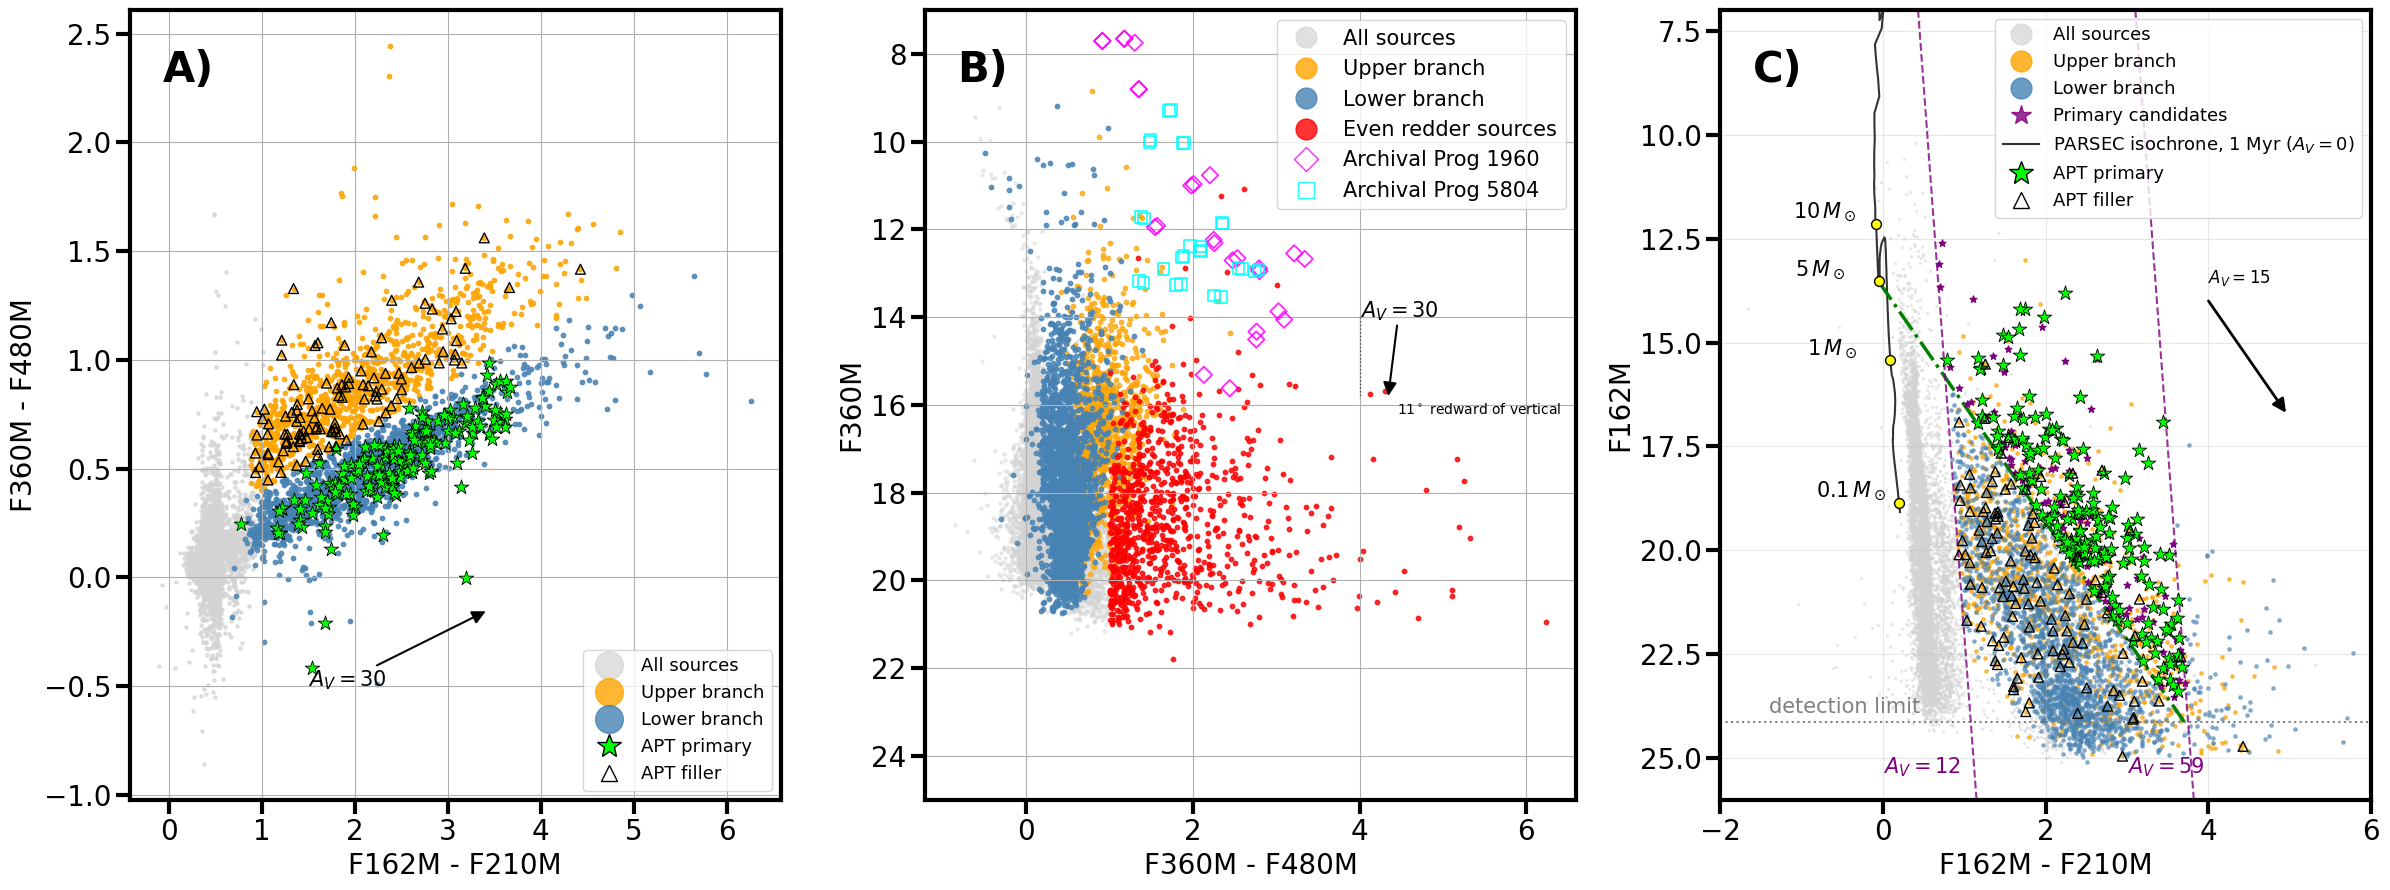

In [48]:
import matplotlib as mpl
plt.rcParams['axes.labelsize']=20 
plt.rcParams['xtick.labelsize']=20
plt.rcParams['ytick.labelsize']=20
plt.rcParams['axes.titlesize']=20
mpl.rcParams['axes.linewidth'] = 3
plt.rcParams['xtick.major.size'] = 10
plt.rcParams['xtick.major.width'] = 3
plt.rcParams['ytick.major.size'] = 10
plt.rcParams['ytick.major.width'] = 3
# true (curved) PARSEC isochrone at A_V=0, with markers at a few reference masses
true_color = F162Mmag_av0[age_idx] - F210Mmag_av0[age_idx]
true_mag = F162Mmag_av0[age_idx]
mass_markers = [0.1, 1, 5, 10]

# mass-cut reddening track through the true anchor point: solid over the bias-free A_V window,
# faded/dotted beyond A_V_cut where the cut becomes magnitude-limited
av_track_safe = np.linspace(0, av_cut, 25)
av_track_unsafe = np.linspace(av_cut, 70, 25)
track_color_safe = color0 + av_track_safe * dcolor_per_av
track_mag_safe = mag0 + av_track_safe * dmag_per_av
track_color_unsafe = color0 + av_track_unsafe * dcolor_per_av
track_mag_unsafe = mag0 + av_track_unsafe * dmag_per_av

# A_V=12 boundary (lower edge of the window), reddening the linear isochrone approximation
xline_ext = np.linspace(isochrone_x_start - 1.0, isochrone_x_end + 0.5, 50)
yline_ext = color_slope * xline_ext + color_intercept
av12_color = xline_ext + AV_MIN * dcolor_per_av
av12_mag = yline_ext + AV_MIN * dmag_per_av
av59_color = xline_ext + 59 * dcolor_per_av
av59_mag = yline_ext + 59 * dmag_per_av
def plot_extvec_ccd(ax, color1, color2, ext=CT06_MWLoc(), extvec_scale=30, start=None,
                    color='y', head_width=0.5, color1_data=None, color2_data=None, label=None, fontsize=15):
    def get_wave(c):
        if c == '410m405': return 4.10*u.um
        if c == '405m410': return 4.05*u.um
        if c == 'Hmag': return 1.634*u.um
        if c == 'Ksmag': return 2.143527*u.um
        return int(c[1:-1])/100*u.um

    w1 = get_wave(color1[0])
    w2 = get_wave(color1[1])
    w3 = get_wave(color2[0])
    w4 = get_wave(color2[1])

    if w1 > w2:
        w1, w2 = w2, w1
        color1 = color1[::-1]
    if w3 > w4:
        w3, w4 = w4, w3
        color2 = color2[::-1]
    print(w1,w2,w3,w4)

    # Only plot if all are in valid range
    try:
        e_1 = ext(1/w1) * extvec_scale
        e_2 = ext(1/w2) * extvec_scale
        e_3 = ext(1/w3) * extvec_scale
        e_4 = ext(1/w4) * extvec_scale
    except ValueError as e:
        print(f"Extinction vector not plotted: {e}")
        return
    print(w1,w2,w3,w4)
    print(e_1, e_2, e_3, e_4)
    if start == None:
        mean_color1 = np.nanmean(color1_data)
        mean_color2 = np.nanmean(color2_data)
        std_color1 = np.nanstd(color1_data)
        std_color2 = np.nanstd(color2_data)
        if e_1 - e_2 < 0:
            std_color1 *= -1
        if e_3 - e_4 < 0:
            std_color2 *= -1
    
        start2 = (mean_color1 + 2*std_color1, mean_color2 + 2*std_color2)
    else:
        start2 = start

    ax.annotate(f'$A_V={extvec_scale}$', xy=(start2[0] + (e_1 - e_2), start2[1] + (e_3 - e_4)),
                xytext=(start2[0], start2[1]), fontsize=fontsize,
                arrowprops=dict(arrowstyle='-|>', color=color,
                                shrinkA=0, shrinkB=0,
                                mutation_scale=20, linewidth=1.5))
    
    if label is not None:
        ax.plot([], [], color=color, marker='>', markersize=8,
                label=f'{label}', linestyle='-', linewidth=2)

    else:
        ax.plot([], [], color=color, marker='>', markersize=8,
                linestyle='-', linewidth=2)
def plot_extvec_cmd(ax, color1, mag1, ext=CT06_MWLoc(), extvec_scale=200, start=None,
                    color='y', head_width=0.5, color1_data=None, mag1_data=None, label=None, fontsize=15):
    def get_wave(c):
        if c == '410m405': return 4.10*u.um
        if c == '405m410': return 4.05*u.um
        if c == 'Hmag': return 1.634*u.um
        if c == 'Ksmag': return 2.143527*u.um
        return int(c[1:-1])/100*u.um

    w1 = get_wave(color1[0])
    w2 = get_wave(color1[1])
    w3 = get_wave(mag1[0])

    if w1 > w2:
        w1, w2 = w2, w1
        color1 = color1[::-1]
    print(w1,w2,w3)

    # Only plot if all are in valid range
    try:
        e_1 = ext(1/w1) * extvec_scale
        e_2 = ext(1/w2) * extvec_scale
        e_3 = ext(1/w3) * extvec_scale
    except ValueError as e:
        print(f"Extinction vector not plotted: {e}")
        return
    print(w1,w2,w3)
    print(e_1, e_2, e_3)
    if start == None:
        mean_color1 = np.nanmean(color1_data)
        mean_mag1 = np.nanmean(mag1_data)
        std_color1 = np.nanstd(color1_data)
        std_mag1 = np.nanstd(mag1_data)
        if e_1 - e_2 < 0:
            std_color1 *= -1
        
    
        start2 = (mean_color1 + 2*std_color1, mean_mag1 + 2*std_mag1)
    else:
        start2 = start
    
    # Strip units for plotting if present
    if hasattr(start2[0], 'value'):
        start2_x = start2[0].value
        start2_y = start2[1].value
    else:
        start2_x = start2[0]
        start2_y = start2[1]

    ax.annotate(f'$A_V={extvec_scale}$', xy=(start2_x + (e_1 - e_2), start2_y + e_3),
                xytext=(start2_x, start2_y), fontsize=15,
                arrowprops=dict(arrowstyle='-|>', color=color,
                                shrinkA=0, shrinkB=0,
                                mutation_scale=20, linewidth=1.5))
    # vertical reference line + explicit tilt angle: e_1 > e_2 here (shorter wavelength =
    # more extinction), so this vector always tilts toward +x (redder), never toward -x
    # (bluer) -- the near-vertical shaft is easy to misjudge as leaning left without this.
    tilt_deg = np.degrees(np.arctan2(e_1 - e_2, e_3))
    ax.plot([start2_x, start2_x], [start2_y, start2_y + e_3], color=color, ls=':', lw=1, alpha=0.6)
    ax.annotate(f'{tilt_deg:.0f}$^\circ$ redward of vertical', xy=(start2_x + (e_1 - e_2), start2_y + e_3),
                xytext=(6, -4), textcoords='offset points', fontsize=10, color=color, ha='left', va='top')
    if label is not None:
        ax.plot([], [], color=color, marker='>', markersize=8,
                label=f'{label}', linestyle='-', linewidth=2)

    else:
        ax.plot([], [], color=color, marker='>', markersize=8,
                linestyle='-', linewidth=2)
def plot_extinction_vector(ax, start, av_scale, dcolor_per_av, dmag_per_av, color='black', fontsize=12):
    """Draw the CT06 MWLoc dust-extinction vector in the CMD: an arrow of length av_scale
    (in A_V) starting at `start`, pointing in the direction reddening actually moves a source."""
    dx = av_scale * dcolor_per_av
    dy = av_scale * dmag_per_av
    ax.annotate('', xy=(start[0] + dx, start[1] + dy), xytext=start,
                arrowprops=dict(arrowstyle='-|>', color=color, lw=2, mutation_scale=20,
                                 shrinkA=0, shrinkB=0))
    ax.text(start[0], start[1] - 0.3, f'$A_V={av_scale}$', color=color, fontsize=fontsize, ha='left', va='bottom')


fig =  plt.figure(figsize=(24, 9))
ax0 = fig.add_subplot(131)
ax0.scatter(f162 - f210, f360 - f480, s=5, c='lightgray', alpha=0.7, label='All sources')
ax0.scatter((f162 - f210)[upper_idx], (f360 - f480)[upper_idx], s=10, c='orange', alpha=0.8,
            label=f'Upper branch')
ax0.scatter((f162 - f210)[lower_idx], (f360 - f480)[lower_idx], s=10, c='steelblue', alpha=0.8,
            label=f'Lower branch')      

ax0.set_xlabel('F162M - F210M')
ax0.set_ylabel('F360M - F480M')
manual_handle = [plt.Line2D([0], [0], marker='o',  label='All sources',
                            color='lightgray', linestyle='None', markersize=20, alpha=0.7),
                 plt.Line2D([0], [0], marker='o', label='Upper branch',
                            color='orange', linestyle='None', markersize=20, alpha=0.8),
                 plt.Line2D([0], [0], marker='o', linestyle='None', label='Lower branch',
                            color='steelblue', markersize=20, alpha=0.8)]
ax0.legend(handles=manual_handle,fontsize=15, loc='lower right')
ax0.grid()
plot_extvec_ccd(ax0, color1=('f162m', 'f210m'), color2=('f360m', 'f480m'), ext=CT06_MWLoc(),
                 extvec_scale=30, start=(1.5, -0.5), color='black', head_width=0.5, color1_data=f162 - f210, color2_data=f360 - f480, label='CT06 dust extinction vector', fontsize=15)

# APT MOS primary/filler targets (see the cross-matching cell above), on the CCD
ax0.scatter((f162 - f210)[apt_primary_mask], (f360 - f480)[apt_primary_mask], s=120, marker='*',
            facecolor='lime', edgecolor='k', linewidths=0.6, zorder=6, label='APT primary')
ax0.scatter((f162 - f210)[apt_filler_mask], (f360 - f480)[apt_filler_mask], s=50, marker='^',
            facecolor='none', edgecolor='k', linewidths=1.0, zorder=6, label='APT filler')
ax0.legend(handles=manual_handle + [
    plt.Line2D([0], [0], marker='*', linestyle='None', label='APT primary',
               markerfacecolor='lime', markeredgecolor='k', markersize=18),
    plt.Line2D([0], [0], marker='^', linestyle='None', label='APT filler',
               markerfacecolor='none', markeredgecolor='k', markersize=12),
], fontsize=13, loc='lower right')

missing_nir_idx = ~np.isfinite(f162) | ~np.isfinite(f210)
very_red_idx = missing_nir_idx & ((f360 - f480) > 1)

ax1 = fig.add_subplot(132)
ax1.scatter(f360 - f480, f360, s=5, c='lightgray', alpha=0.4, label='All sources')
ax1.scatter((f360 - f480)[upper_idx], f360[upper_idx], s=10, c='orange', alpha=0.7,
            label=f'Upper branch')
ax1.scatter((f360 - f480)[lower_idx], f360[lower_idx], s=10, c='steelblue', alpha=0.8,
            label=f'Lower branch')
ax1.scatter((f360 - f480)[very_red_idx], f360[very_red_idx], s=10, c='red', alpha=0.8,
            label=f'Even redder sources')

archival_color = (archival_mag['f360m'] - archival_mag['f480m']).to_value(u.mag)
archival_f360 = archival_mag['f360m'].to_value(u.mag)
archival_styles = {1960: dict(facecolor='none', edgecolor='magenta', marker='D'),
                    5804: dict(facecolor='none', edgecolor='cyan', marker='s')}
for prog, style in archival_styles.items():
    prog_mask = (archival_program == prog) & np.isfinite(archival_color) & np.isfinite(archival_f360)
    ax1.scatter(archival_color[prog_mask], archival_f360[prog_mask], s=70, linewidth=1.3, alpha=0.85, zorder=5,
                label=f'Archival Prog {prog}', **style)

ax1.set_xlabel('F360M - F480M')
ax1.set_ylabel('F360M')
ax1.set_ylim(25, 7)

manual_handle = [plt.Line2D([0], [0], marker='o',  label='All sources',
                            color='lightgray', linestyle='None', markersize=15, alpha=0.7),
                 plt.Line2D([0], [0], marker='o', label='Upper branch',
                            color='orange', linestyle='None', markersize=15, alpha=0.8),
                 plt.Line2D([0], [0], marker='o', linestyle='None', label='Lower branch',
                            color='steelblue', markersize=15, alpha=0.8),
                 plt.Line2D([0], [0], marker='o', linestyle='None', label='Even redder sources',
                            color='red', markersize=15, alpha=0.8),
                 plt.Line2D([0], [0], marker='D', linestyle='None', label='Archival Prog 1960',
                            markerfacecolor='none', markeredgecolor='magenta', markersize=12, alpha=0.85),
                 plt.Line2D([0], [0], marker='s', linestyle='None', label='Archival Prog 5804',
                            markerfacecolor='none', markeredgecolor='cyan', markersize=12, alpha=0.85)]
ax1.legend(handles=manual_handle, fontsize=15)
ax1.grid()


plot_extvec_cmd(ax1, color1=('f360m', 'f480m'), mag1=('f360m',), ext=CT06_MWLoc(),
                extvec_scale=30, start=(4, 14), color='black', head_width=0.5, color1_data=f360 - f480, mag1_data=f360,  fontsize=15)


ax = fig.add_subplot(133)

ax.scatter(f162 - f210, f162, s=2, c='lightgray', alpha=0.4, label='All sources')
ax.scatter((f162 - f210)[upper_idx], f162[upper_idx], s=6, c='orange', alpha=0.6,
           label=f'Upper branch')
ax.scatter((f162 - f210)[lower_idx], f162[lower_idx], s=6, c='steelblue', alpha=0.5,
           label=f'Lower branch')
ax.scatter((f162 - f210)[final_mask], f162[final_mask], s=25, c='purple', marker='*', zorder=4,
           label=f'Primary candidates')

# true isochrone + mass markers
ax.plot(true_color, true_mag, color='black', lw=1.5, alpha=0.8, label='PARSEC isochrone, 1 Myr ($A_V=0$)')
for m in mass_markers:
    idx_m = np.argmin(np.abs(mass_av0[age_idx] - m))
    cx, cy = true_color[idx_m], true_mag[idx_m]
    ax.scatter(cx, cy, color='yellow', marker='o', s=50, zorder=5, edgecolor='k', linewidth=1)
    ax.annotate(f'{m}' + r'$\,M_\odot$', (cx, cy), textcoords='offset points', xytext=(-60, 4),
                fontsize=15, color='black')

# linear isochrone approximation used only for the overall A_V estimate
xline = np.array([isochrone_x_start, isochrone_x_end])
#ax.plot(xline, color_slope * xline + color_intercept, 'k--', lw=1.5, alpha=0.6,
#        label=f'Linear isochrone approx. ({MASS_LOW}-{MASS_HIGH} $M_\odot$, for $A_V$)')

# mass-cut boundary through the true anchor: bias-free window solid, magnitude-limited part faded/dotted
ax.plot(track_color_safe, track_mag_safe, color='green', lw=2.5, ls='-.',
        label=f'{mass_threshold} $M_\odot$ cut boundary (true isochrone anchor)')
#ax.plot(track_color_unsafe, track_mag_unsafe, color='green', lw=2.5, ls=':', alpha=0.6,
#        label=f'{mass_threshold} $M_\odot$ cut boundary (mag-limited, excluded)')
#ax.scatter(color0, mag0, marker='x', s=150, color='green', zorder=5)
#ax.scatter(track_color_safe[-1], track_mag_safe[-1], marker='D', s=60, color='black', zorder=6,
#           label=f'$A_V$={av_cut:.0f}: mass cut meets detection limit')

# detection limit and the A_V=12 lower boundary of the window
ax.axhline(mag_lim, color='gray', ls=':', lw=1.5, )
ax.plot(av12_color, av12_mag, color='purple', ls='--', lw=1.5, alpha=0.8,)
ax.plot(av59_color, av59_mag, color='purple', ls='--', lw=1.5, alpha=0.8,)

# CT06 dust extinction vector, placed in an empty corner of the CMD for reference
plot_extinction_vector(ax, start=(4,14), av_scale=15, dcolor_per_av=dcolor_per_av, dmag_per_av=dmag_per_av)
ax.plot([], [], color='black', marker='>', linestyle='-', linewidth=2)

ax.set_xlabel('F162M - F210M')
ax.set_ylabel('F162M')
ax.set_ylim(26, 7)
ax.set_xlim(-2, 6)
ax.scatter((f162 - f210)[apt_primary_mask], f162[apt_primary_mask], s=120, marker='*',
           facecolor='lime', edgecolor='k', linewidths=0.6, zorder=6)
ax.scatter((f162 - f210)[apt_filler_mask], f162[apt_filler_mask], s=50, marker='^',
           facecolor='none', edgecolor='k', linewidths=1.0, zorder=6)

manual_handle = [plt.Line2D([0], [0], marker='o',  label='All sources',
                            color='lightgray', linestyle='None', markersize=15, alpha=0.7),
                 plt.Line2D([0], [0], marker='o', label='Upper branch',
                            color='orange', linestyle='None', markersize=15, alpha=0.8),
                 plt.Line2D([0], [0], marker='o', linestyle='None', label='Lower branch',   
                            color='steelblue', markersize=15, alpha=0.8),
                 plt.Line2D([0], [0], marker='*', linestyle='None', label='Primary candidates',
                            color='purple', markersize=15, alpha=0.8),
                 plt.Line2D([0], [0], marker='None', linestyle='-', color='k', label='PARSEC isochrone, 1 Myr ($A_V=0$)', lw=1.5, alpha=0.8),
                 plt.Line2D([0], [0], marker='*', linestyle='None', label='APT primary',
                            markerfacecolor='lime', markeredgecolor='k', markersize=18),
                 plt.Line2D([0], [0], marker='^', linestyle='None', label='APT filler',
                            markerfacecolor='none', markeredgecolor='k', markersize=12)]
ax.legend(handles=manual_handle, fontsize=13, loc='upper right')
ax.grid(alpha=0.3)
ax.text(-1.4, 24, 'detection limit', fontsize=15, color='gray', rotation=0, ha='left', va='bottom')
ax.text(0., 25.5, r'$A_V=12$', fontsize=15, color='purple', rotation=0, ha='left', va='bottom')
ax.text(3., 25.5, r'$A_V=59$', fontsize=15, color='purple', rotation=0, ha='left', va='bottom')

ax0.text(0.05, 0.95, 'A)', transform=ax0.transAxes, fontsize=30, fontweight='bold', va='top', ha='left')
ax1.text(0.05, 0.95, 'B)', transform=ax1.transAxes, fontsize=30, fontweight='bold', va='top', ha='left')
ax.text(0.05, 0.95, 'C)', transform=ax.transAxes, fontsize=30, fontweight='bold', va='top', ha='left')
plt.tight_layout()

plt.savefig('nirspec_mos_lower_branch_mass_cut.png', bbox_inches='tight')
plt.show()


## Aside: why does dust extinction make F360M$-$F480M *redder*, not bluer?

The CT06 extinction curve decreases monotonically from 1 to 5 $\mu$m -- that part is correct. But "decreasing extinction with wavelength" means F360M (3.6 $\mu$m, shorter wavelength) is extinguished **more** than F480M (4.8 $\mu$m, longer wavelength), not less. As $A_V$ increases, F360M dims by more magnitudes than F480M does, so F360M$-$F480M **increases** -- that is the standard, expected reddening direction (same sense as F162M$-$F210M reddening in the other panel), not bluer.

So the extinction vector drawn on the F360M$-$F480M vs F360M panel should point down (fainter) *and* to the right (redder). Below: the CT06 curve itself, then the actual vector geometry used by `plot_extvec_cmd`.

A(3.6um)/A_V = 0.0600   A(4.8um)/A_V = 0.0485   A(3.6um) - A(4.8um) = 0.0115  (> 0)


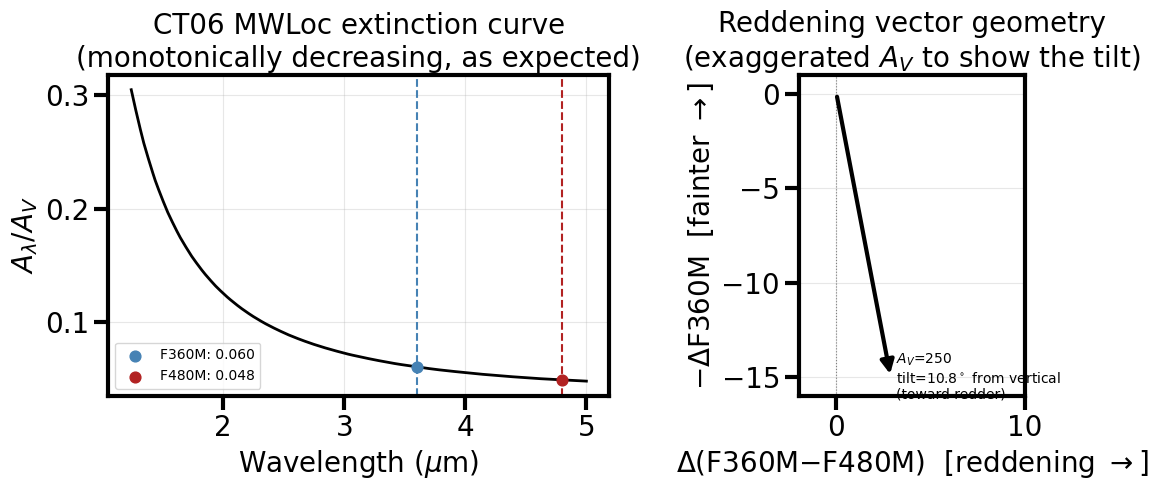

At the A_V=30 scale used in the CMD panel: dx=0.345, dy=1.799 -- the vector tilts only 10.8 deg from straight down, toward redder (+x), not bluer.
The near-vertical arrow in the CMD above is easy to misread as leaning left at that scale --
it is dominated by the (much larger) fainter/vertical term, with a small but genuine rightward lean.


In [49]:
ct06_wave = np.linspace(1.24, 5.0, 400) * u.um  # 1.24 um = CT06_MWLoc's short-wavelength validity limit
ct06_curve = ext(1 / ct06_wave)

A_360 = float(ext(1 / (3.6 * u.um)))
A_480 = float(ext(1 / (4.8 * u.um)))
print(f'A(3.6um)/A_V = {A_360:.4f}   A(4.8um)/A_V = {A_480:.4f}   A(3.6um) - A(4.8um) = {A_360 - A_480:.4f}  (> 0)')

fig, (axc, axv) = plt.subplots(1, 2, figsize=(12, 5))

axc.plot(ct06_wave.value, ct06_curve, color='k', lw=2)
axc.axvline(3.6, color='steelblue', ls='--')
axc.axvline(4.8, color='firebrick', ls='--')
axc.scatter([3.6], [A_360], color='steelblue', zorder=5, s=60, label=f'F360M: {A_360:.3f}')
axc.scatter([4.8], [A_480], color='firebrick', zorder=5, s=60, label=f'F480M: {A_480:.3f}')
axc.set_xlabel('Wavelength ($\mu$m)')
axc.set_ylabel(r'$A_\lambda / A_V$')
axc.set_title('CT06 MWLoc extinction curve\n(monotonically decreasing, as expected)')
axc.legend()
axc.grid(alpha=0.3)

# the actual reddening-vector geometry used by plot_extvec_cmd on the F360M-F480M vs F360M panel,
# exaggerated to A_V=250 so the (small but real) rightward tilt is visible
av_demo = 250
dx = (A_360 - A_480) * av_demo   # color1=('f360m','f480m'): e_1 - e_2, always > 0
dy = A_360 * av_demo             # mag1=('f360m',): e_3 = e_1 (same filter as the blue edge of the color)
tilt_deg = np.degrees(np.arctan2(dx, dy))

axv.annotate('', xy=(dx, -dy), xytext=(0, 0),
             arrowprops=dict(arrowstyle='-|>', color='black', lw=3, mutation_scale=20))
axv.text(dx + 0.3, -dy, f'$A_V$={av_demo}\ntilt={tilt_deg:.1f}$^\circ$ from vertical\n(toward redder)', va='center')
axv.axvline(0, color='gray', lw=0.8, ls=':')
axv.set_xlim(-2, 10)
axv.set_ylim(-16, 1)
axv.set_xlabel(r'$\Delta$(F360M$-$F480M)  [reddening $\rightarrow$]')
axv.set_ylabel(r'$-\Delta$F360M  [fainter $\rightarrow$]')
axv.set_title('Reddening vector geometry\n(exaggerated $A_V$ to show the tilt)')
axv.set_aspect('equal')
axv.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('ct06_extinction_curve_explainer.png', bbox_inches='tight')
plt.show()

print(f'At the A_V=30 scale used in the CMD panel: dx={(A_360-A_480)*30:.3f}, dy={A_360*30:.3f} '
      f'-- the vector tilts only {tilt_deg:.1f} deg from straight down, toward redder (+x), not bluer.')
print('The near-vertical arrow in the CMD above is easy to misread as leaning left at that scale --')
print('it is dominated by the (much larger) fainter/vertical term, with a small but genuine rightward lean.')


## Candidate table: lower branch (mass + $A_V$ cut), upper branch, and the "very red" sources

Adds a third population from `color_magnitude_diagram_cleancat.ipynb`: sources with no finite F140M/F162M *or* F210M detection at all (too embedded/reddened to appear in the near-IR bands used for this CMD) that are still very red in F360M-F480M ($>1.5$ mag) -- the most deeply embedded protostars, which this NIR CMD cannot place a mass or $A_V$ on. Together with the lower-branch NIRSpec candidates and the upper branch, this is the same three-population split used for the spatial-distribution maps in the reference notebook.

The three groups are disjoint by construction: the upper/lower branch masks require finite F162M and F210M (needed for `av_estimate`), while the "very red" mask requires at least one of them to be missing.

In [50]:


print(f'N missing F162M or F210M: {missing_nir_idx.sum()}')
print(f'N very red (missing NIR, F360M-F480M > 1.5): {very_red_idx.sum()}')


def build_candidate_table(mask, population_name):
    """Catalog rows for `mask`, tagged with a population label and the computed photometry."""
    sub = catalog[mask].copy()
    sub['F162M_vegamag'] = f162[mask]
    sub['F210M_vegamag'] = f210[mask]
    sub['F360M_vegamag'] = f360[mask]
    sub['F480M_vegamag'] = f480[mask]
    sub['A_V_estimate'] = av_estimate[mask]
    sub['population'] = population_name
    return sub


lower_branch_table = build_candidate_table(final_mask, f'lower_branch_M>{mass_threshold}Msun_AVcut')
upper_branch_table = build_candidate_table(upper_idx, 'upper_branch')
very_red_table = build_candidate_table(very_red_idx, 'very_red_missing_nir')

from astropy.table import vstack
nirspec_mos_candidates = vstack(
    [lower_branch_table, upper_branch_table, very_red_table], metadata_conflicts='silent')

print(f'N lower branch (selected): {len(lower_branch_table)}')
print(f'N upper branch: {len(upper_branch_table)}')
print(f'N very red: {len(very_red_table)}')
print(f'N total candidates: {len(nirspec_mos_candidates)}')

nirspec_mos_candidates.write('nirspec_mos_candidates.ecsv', overwrite=True)
nirspec_mos_candidates[['skycoord_ref', 'F162M_vegamag', 'F210M_vegamag', 'F360M_vegamag',
                         'F480M_vegamag', 'A_V_estimate', 'population']][:10]


N missing F162M or F210M: 2474
N very red (missing NIR, F360M-F480M > 1.5): 924


N lower branch (selected): 267
N upper branch: 1106
N very red: 924
N total candidates: 2297


skycoord_ref,F162M_vegamag,F210M_vegamag,F360M_vegamag,F480M_vegamag,A_V_estimate,population
"deg,deg",,,,,,
SkyCoord,float64,float64,float64,float64,float64,str26
"290.925727599285,14.548970161190942",19.242551415573622,16.914729894821843,14.99968860360945,14.41150055826184,37.24156885639592,lower_branch_M>5Msun_AVcut
"290.92400512237276,14.551182959941807",21.522635331880956,18.536142354525996,16.310432007232677,15.559122431564925,47.31499206278306,lower_branch_M>5Msun_AVcut
"290.9265275542042,14.540288842048177",19.152632869492642,17.13170948004981,15.387282973923043,14.885747918330367,31.900812358560795,lower_branch_M>5Msun_AVcut
"290.9209866429556,14.547720726744556",20.135499534257573,17.79993474190074,15.843912560752942,15.249785308899487,36.783547200438605,lower_branch_M>5Msun_AVcut
"290.9208692033008,14.547808000896937",18.714950075040726,16.411023949934133,14.467227984566984,14.040464985227208,37.17220673668779,lower_branch_M>5Msun_AVcut
"290.9203432028775,14.548384002123306",20.22819651397688,17.68392136120237,15.588680805069654,15.068745531866712,40.39460805895931,lower_branch_M>5Msun_AVcut
"290.9210595497845,14.543455438665172",19.25668412393987,16.13328552343058,13.602183759800637,12.929800928052169,51.23222718120378,lower_branch_M>5Msun_AVcut
"290.92074229478015,14.534344419730042",16.08832291851321,15.153907786886052,14.272026361506004,14.072669741019304,14.82051193015134,lower_branch_M>5Msun_AVcut


## MOS planning tables: the full catalog, priority-weighted, split left/right by F480M pixel position

Every source in the working catalog (not just the three populations above) is written out, split into a left and right half by x pixel position in the F480M mosaic (e.g. for two separate pointings/dithers covering the field), with a priority weight:

- **Lower branch** (`mass_threshold`-$M_\odot$, $A_V$-windowed cut): weight = 3 (highest priority -- the NIRSpec massive-YSO candidates this notebook was built to select)
- **Very red** (missing-NIR, deeply embedded) sources: weight = 2
- **Upper branch**: weight = 1
- **Everything else** (not in any of the three populations): weight = 0

The three non-zero populations are disjoint by construction (see above), so each source gets exactly one weight. Each table has columns `ID` (the source's row index in the working catalog, for traceability back to the full photometric catalog), `RA`/`DEC` (ICRS, equivalent to J2000 for this purpose), and `weight`.

In [51]:
# x pixel position in the F480M mosaic, to split the field into left/right halves
wcs_f480m = WCS(headers['f480m'])
pix_x, pix_y = wcs_f480m.world_to_pixel(catalog['skycoord_ref'])
x_mid = headers['f480m']['NAXIS1'] / 2

left_mask = pix_x < x_mid
right_mask = ~left_mask
print(f'F480M NAXIS1={headers["f480m"]["NAXIS1"]}, splitting at x={x_mid:.0f} px '
      f'(N left={left_mask.sum()}, N right={right_mask.sum()})')

# priority weight for every source in the catalog: lower branch (selected) = 3, very red = 2,
# upper branch = 1, everything else (the rest of the catalog) = 0
upper_mask = np.zeros(f162.shape, dtype=bool)
upper_mask[upper_idx] = True

weight_all = np.zeros(f162.shape)
weight_all[upper_mask] = 1
weight_all[very_red_idx] = 2
weight_all[final_mask] = 3


def build_mos_table(mask, weights):
    """MOS planning table (ID, RA, DEC, weight) for the sources selected by `mask`.
    `weights` is either a scalar (same weight for every row) or a per-source array."""
    sc = catalog['skycoord_ref'][mask]
    w = np.full(mask.sum(), weights) if np.isscalar(weights) else weights[mask]
    return Table({'ID': np.where(mask)[0], 'RA': sc.ra.deg, 'DEC': sc.dec.deg, 'weight': w})


# split the full, weighted catalog into left/right -- two final catalogs, all sources included
nirspec_mos_left = build_mos_table(left_mask, weight_all)
nirspec_mos_right = build_mos_table(right_mask, weight_all)

mos_tables = {'left': nirspec_mos_left, 'right': nirspec_mos_right}
for name, tab in mos_tables.items():
    tab.write(f'nirspec_mos_{name}.csv', format='ascii.no_header', delimiter=',', overwrite=True)
    n_w3 = (tab['weight'] == 3).sum()
    n_w2 = (tab['weight'] == 2).sum()
    n_w1 = (tab['weight'] == 1).sum()
    n_w0 = (tab['weight'] == 0).sum()
    print(f'{name}: N={len(tab)} (weight=3: {n_w3}, weight=2: {n_w2}, weight=1: {n_w1}, weight=0: {n_w0}) '
          f'-> nirspec_mos_{name}.csv')

nirspec_mos_left[:5]


F480M NAXIS1=5645, splitting at x=2822 px (N left=8409, N right=6595)
left: N=8409 (weight=3: 158, weight=2: 436, weight=1: 610, weight=0: 7205) -> nirspec_mos_left.csv
right: N=6595 (weight=3: 109, weight=2: 488, weight=1: 496, weight=0: 5502) -> nirspec_mos_right.csv


ID,RA,DEC,weight
int64,float64,float64,float64
0,290.93209452203126,14.536869867429246,0.0
1,290.932199066597,14.536560364925867,0.0
2,290.9251936766804,14.552144990935817,0.0
3,290.9275928328416,14.546812410608284,0.0
4,290.9306212815275,14.540014273453073,0.0


## Spatial 2x2 figure: APT targets on the field, and each population's density

Top-left: the F480M mosaic with the APT-selected primary/filler MOS targets, and the W51-E and W51-IRS2 protocluster centers marked (mean position of the ALMA-matched driving sources used for these clusters in `color_magnitude_diagram_cleancat.ipynb`, i.e. `w51e_matched_idx`/`w51n_matched_idx`).

The other three panels reproduce the population density-fraction maps from that same reference notebook (KDE per population, normalized by the summed KDE of all three, so each panel shows *where a given population dominates* rather than raw density) for lower branch, upper branch, and the very-red sources, with the 870 $\mu$m continuum contour overlaid the same way (the `co_plank` map: despite its name/filename, this is confirmed in the reference notebook to be the ATLASGAL 870 $\mu$m continuum reprojected onto the F480M grid, in Jy/beam).

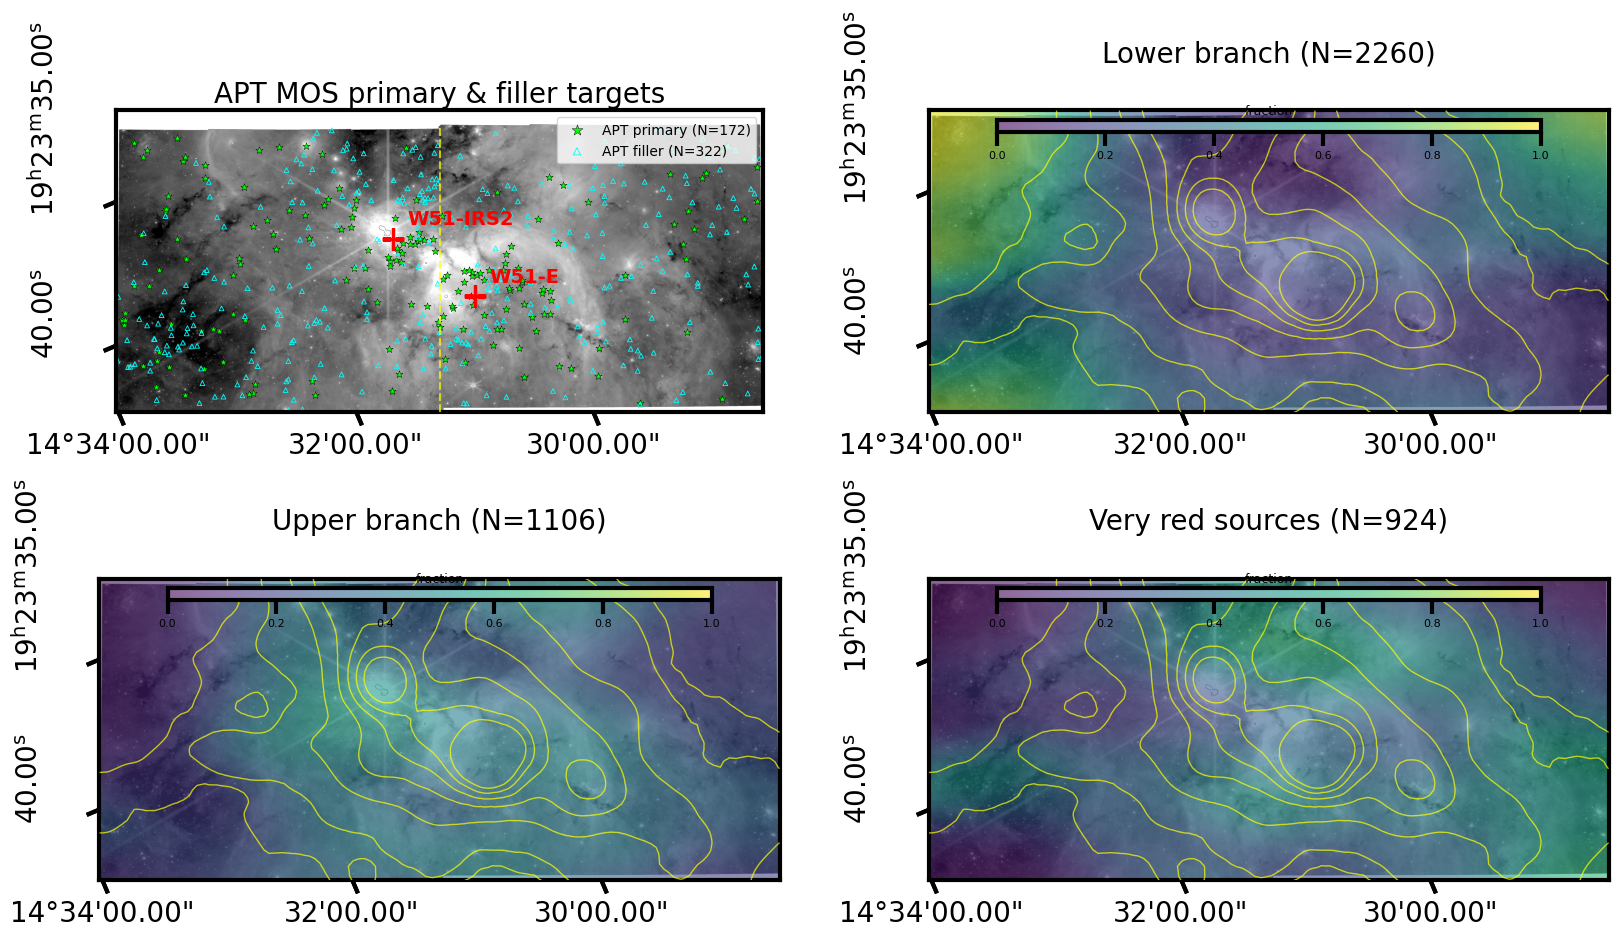

In [57]:
from matplotlib.gridspec import GridSpec
from astropy.visualization import simple_norm
from scipy.stats import gaussian_kde

wcs_f480m = WCS(headers['f480m'])
f480m_data = fits.getdata(image_filenames['f480m'], ext=('SCI', 1))
norm_f480m = simple_norm(f480m_data, stretch='log', percent=99.)

pixcoord_ref = wcs_f480m.all_world2pix(catalog['skycoord_ref'].ra.deg, catalog['skycoord_ref'].dec.deg, 0)

# despite the variable name, this is the ATLASGAL 870um continuum map (Jy/beam), reprojected
# onto the F480M pixel grid -- see the note in color_magnitude_diagram_cleancat.ipynb
co_planck_fn = '/orange/adamginsburg/jwst/w51/data_reprojected_480/co_planck_reprojected_to_f480m.fits'
co_plank = fits.getdata(co_planck_fn, ext=0)


def format_wcs_axes(ax):
    ra = ax.coords['ra']
    dec = ax.coords['dec']
    ra.set_major_formatter('hh:mm:ss.ss')
    dec.set_major_formatter('dd:mm:ss.ss')
    ra.set_ticklabel(rotation=90, pad=30)
    ra.set_ticks_position('l')
    ra.set_ticklabel_position('l')
    ra.set_axislabel('')
    dec.set_ticks_position('b')
    dec.set_ticklabel_position('b')
    dec.set_axislabel('')


# W51-E / W51-IRS2 protocluster centers: mean position of the ALMA-matched driving sources
# used for these clusters in color_magnitude_diagram_cleancat.ipynb (w51e_matched_idx for
# W51-E, w51n_matched_idx for W51-IRS2)
w51e_center = SkyCoord(ra=290.9316 * u.deg, dec=14.5097 * u.deg)
w51irs2_center = SkyCoord(ra=290.9183 * u.deg, dec=14.5178 * u.deg)
w51e_pix = wcs_f480m.world_to_pixel(w51e_center)
w51irs2_pix = wcs_f480m.world_to_pixel(w51irs2_center)

fig = plt.figure(figsize=(20, 10))
gs = GridSpec(2, 2, figure=fig, hspace=0.55, wspace=0.15)

# --- top-left: F480M image + APT primary/filler targets + protocluster labels ---
ax_img = fig.add_subplot(gs[0, 0], projection=wcs_f480m)
ax_img.imshow(f480m_data, origin='lower', cmap='gray', norm=norm_f480m)
ax_img.scatter(pixcoord_ref[0][apt_primary_mask], pixcoord_ref[1][apt_primary_mask], s=30, marker='*',
               facecolor='lime', edgecolor='k', linewidths=0.3, label=f'APT primary (N={apt_primary_mask.sum()})')
ax_img.scatter(pixcoord_ref[0][apt_filler_mask], pixcoord_ref[1][apt_filler_mask], s=12, marker='^',
               facecolor='none', edgecolor='cyan', linewidths=0.6, label=f'APT filler (N={apt_filler_mask.sum()})')
for center_pix, name in [(w51e_pix, 'W51-E'), (w51irs2_pix, 'W51-IRS2')]:
    ax_img.scatter(*center_pix, s=250, marker='+', color='red', linewidths=2.5, zorder=6)
    ax_img.annotate(name, center_pix, color='red', fontsize=14, fontweight='bold',
                     xytext=(10, 10), textcoords='offset points')
ax_img.legend(fontsize=10, loc='upper right', markerscale=1.5)
format_wcs_axes(ax_img)
ax_img.set_title('APT MOS primary & filler targets')
# draw a vertical line to split the field into left/right halves for the MOS planning tables
ax_img.vlines(x_mid, 0, f480m_data.shape[0], color='yellow', ls='--', lw=1.5, alpha=0.7)

# --- other three: KDE density fraction of each population, with the 870um contour ---
populations = [
    ('Lower branch', lower_idx, gs[0, 1]),
    ('Upper branch', upper_idx, gs[1, 0]),
    ('Very red sources', very_red_idx, gs[1, 1]),
]

xgrid = np.linspace(0, f480m_data.shape[1], 100)
ygrid = np.linspace(0, f480m_data.shape[0], 100)
Xgrid, Ygrid = np.meshgrid(xgrid, ygrid)
grid_points = np.vstack([Xgrid.ravel(), Ygrid.ravel()])

kdes = {}
for label, idx_mask, _ in populations:
    xy = np.vstack([pixcoord_ref[0][idx_mask], pixcoord_ref[1][idx_mask]])
    kde = gaussian_kde(xy)
    kdes[label] = kde(grid_points).reshape(Xgrid.shape)

total = sum(kdes.values()) + 1e-10

for label, idx_mask, slot in populations:
    axi = fig.add_subplot(slot, projection=wcs_f480m)
    axi.imshow(f480m_data, origin='lower', cmap='gray', norm=norm_f480m)
    frac = kdes[label] / total
    im = axi.imshow(
        frac, origin='lower', cmap='viridis', alpha=0.6, vmin=0, vmax=1,
        extent=[xgrid.min(), xgrid.max(), ygrid.min(), ygrid.max()], interpolation='nearest',
    )
    axi.contour(co_plank, levels=[2, 2.78, 5.11, 9.00, 14.44, 21.44, 30.0], colors='yellow', alpha=0.7, linewidths=1)
    cax = axi.inset_axes([0.1, 0.93, 0.8, 0.04], transform=axi.transAxes)
    cbar = plt.colorbar(im, cax=cax, orientation='horizontal')
    cbar.ax.xaxis.set_label_position('top')
    cbar.set_label('fraction', fontsize=9)
    cbar.ax.tick_params(labelsize=8)
    format_wcs_axes(axi)
    n_pop = idx_mask[0].size if isinstance(idx_mask, tuple) else idx_mask.sum()
    axi.set_title(f'{label} (N={n_pop})', pad=35)
plt.tight_layout()
plt.savefig('nirspec_mos_2x2_spatial_populations.png', bbox_inches='tight')
plt.show()
